# Notebook 07 — Feature Selection

## Objective

This notebook performs systematic feature selection on the 39 handcrafted
respiratory-sound features generated in Notebook 05.

The following approaches are used:

1. Correlation-based redundancy filtering
2. ANOVA F-score
3. Mutual Information
4. Random Forest feature importance

The objective is to identify informative and non-redundant features for
the subsequent classical machine-learning experiments.

## Leakage Prevention

Feature selection is performed using the training portion of the dataset
only. The official test recordings are not used to determine feature
selection thresholds or rankings.

This prevents information from the test set from influencing the model
development process.

## Important Dataset Structure

Disease diagnosis is a patient-level label, while individual rows
represent respiratory cycles.

Therefore, patient/recording structure must be preserved throughout
the machine-learning pipeline.

The selected features will be evaluated later using patient-aware
train/test evaluation.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_selection import (
    f_classif,
    mutual_info_classif
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import LabelEncoder

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_DIR = (
    PROJECT_ROOT / "data" / "processed"
)

FEATURES_DIR = (
    PROCESSED_DATA_DIR / "features"
)

ANALYSIS_DIR = (
    PROCESSED_DATA_DIR / "analysis"
)

features_path = (
    FEATURES_DIR /
    "respiratory_cycle_features.csv"
)

features_df = pd.read_csv(features_path)

print("Feature dataset shape:", features_df.shape)

Feature dataset shape: (6898, 52)


In [3]:
metadata_columns = [
    "patient_id",
    "recording_id",
    "chest_location",
    "acquisition_mode",
    "equipment",
    "cycle_number",
    "start_time",
    "end_time",
    "sound_label",
    "crackles",
    "wheezes",
    "diagnosis",
    "processed_path",
]

feature_columns = [
    col
    for col in features_df.columns
    if col not in metadata_columns
]

print("Number of features:", len(feature_columns))

Number of features: 39


In [4]:
interim_files = list(
    (PROJECT_ROOT / "data" / "interim").glob("*")
)

print("Files in data/interim:")
for file in interim_files:
    print("-", file.name)

Files in data/interim:
- .gitkeep
- recordings.csv
- filename_validation.csv
- cycles.csv
- patients.csv
- .ipynb_checkpoints
- cycles_validation.csv
- audio_info.csv


In [5]:
recordings_df = pd.read_csv(
    PROJECT_ROOT /
    "data" /
    "interim" /
    "recordings.csv"
)

print(recordings_df.shape)
display(recordings_df.head())

(920, 7)


,patient_id,recording_id,chest_location,acquisition_mode,equipment,wav_path,official_split
0,101,1b1,Al,sc,Meditron,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,test
1,101,1b1,Pr,sc,Meditron,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,test
2,102,1b1,Ar,sc,Meditron,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,test
3,103,2b2,Ar,mc,LittC2SE,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,train
4,104,1b1,Al,sc,Litt3200,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,test


In [8]:
# ============================================================
# Load Official Recording Split
# ============================================================

recordings_df = pd.read_csv(
    PROJECT_ROOT /
    "data" /
    "interim" /
    "recordings.csv"
)

print("Recording metadata shape:", recordings_df.shape)

display(recordings_df.head())

Recording metadata shape: (920, 7)


,patient_id,recording_id,chest_location,acquisition_mode,equipment,wav_path,official_split
0,101,1b1,Al,sc,Meditron,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,test
1,101,1b1,Pr,sc,Meditron,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,test
2,102,1b1,Ar,sc,Meditron,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,test
3,103,2b2,Ar,mc,LittC2SE,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,train
4,104,1b1,Al,sc,Litt3200,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,test


In [9]:
print("Official split distribution:")

display(
    recordings_df["official_split"]
    .value_counts()
)

Official split distribution:


official_split
train    539
test     381
Name: count, dtype: int64

In [10]:
# ============================================================
# Attach Official Train/Test Split to Cycle Features
# ============================================================

split_columns = [
    "patient_id",
    "recording_id",
    "chest_location",
    "official_split"
]

features_with_split = features_df.merge(
    recordings_df[split_columns],
    on=[
        "patient_id",
        "recording_id",
        "chest_location"
    ],
    how="left",
    validate="many_to_one"
)

print("Features with split shape:", features_with_split.shape)
display(
    features_with_split[
        [
            "patient_id",
            "recording_id",
            "chest_location",
            "official_split"
        ]
    ].head()
)

Features with split shape: (6898, 53)


,patient_id,recording_id,chest_location,official_split
0,101,1b1,Al,test
1,101,1b1,Al,test
2,101,1b1,Al,test
3,101,1b1,Al,test
4,101,1b1,Al,test


In [11]:
print(
    "Missing official split values:",
    features_with_split["official_split"].isna().sum()
)

Missing official split values: 0


In [12]:
# ============================================================
# Prepare Training Data for Feature Selection
# ============================================================

train_df = features_with_split[
    features_with_split["official_split"] == "train"
].copy()

test_df = features_with_split[
    features_with_split["official_split"] == "test"
].copy()

X_train = train_df[feature_columns].copy()

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(
    train_df["diagnosis"]
)

print("Training cycles:", len(train_df))
print("Testing cycles:", len(test_df))
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

Training cycles: 4142
Testing cycles: 2756
X_train shape: (4142, 39)
y_train shape: (4142,)


In [13]:
# ============================================================
# ANOVA F-score
# ============================================================

anova_scores, anova_pvalues = f_classif(
    X_train,
    y_train
)

anova_df = pd.DataFrame({
    "feature": feature_columns,
    "anova_f_score": anova_scores,
    "anova_p_value": anova_pvalues
})

anova_df = anova_df.sort_values(
    "anova_f_score",
    ascending=False
).reset_index(drop=True)

display(anova_df)

,feature,anova_f_score,anova_p_value
0,mfcc_11_mean,117.690044,4.915906e-158
1,spectral_entropy,104.427954,3.556886e-141
2,mfcc_13_mean,97.980855,7.217214e-133
3,mfcc_1_mean,71.301847,1.074909e-97
4,zero_crossing_rate,59.102356,3.540494e-81
5,peak_to_peak,50.371915,3.437150e-69
6,spectral_centroid,49.493648,5.618463e-68
7,spectral_bandwidth,46.761371,3.413310e-64
8,wavelet_entropy,44.760995,2.048272e-61
9,mfcc_8_mean,44.312715,8.608218e-61


In [14]:
top_anova = anova_df.head(15)

display(top_anova)

,feature,anova_f_score,anova_p_value
0,mfcc_11_mean,117.690044,4.915906e-158
1,spectral_entropy,104.427954,3.556886e-141
2,mfcc_13_mean,97.980855,7.217214e-133
3,mfcc_1_mean,71.301847,1.074909e-97
4,zero_crossing_rate,59.102356,3.540494e-81
5,peak_to_peak,50.371915,3.437150e-69
6,spectral_centroid,49.493648,5.618463e-68
7,spectral_bandwidth,46.761371,3.413310e-64
8,wavelet_entropy,44.760995,2.048272e-61
9,mfcc_8_mean,44.312715,8.608218e-61


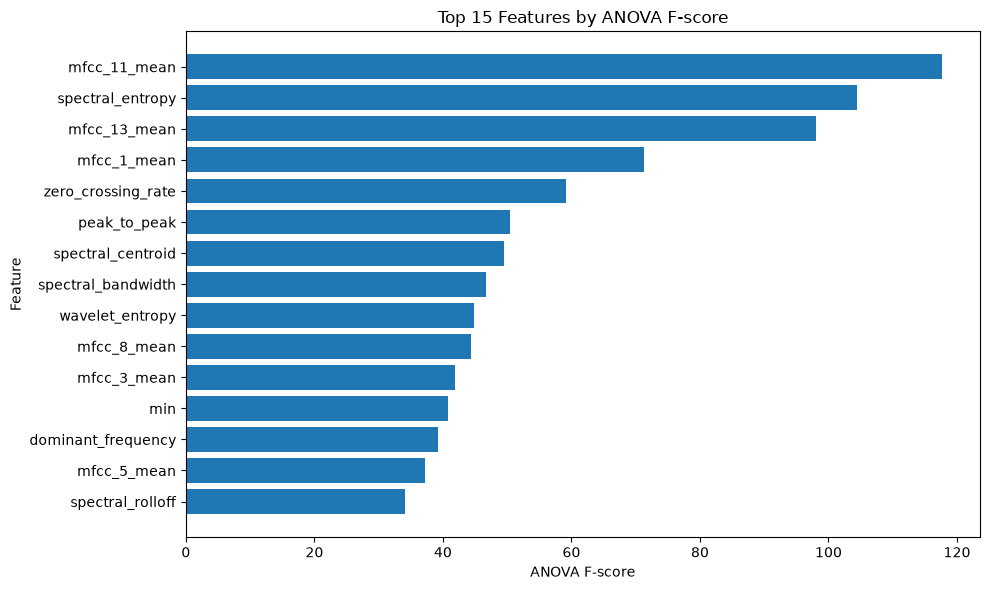

In [15]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_anova["feature"][::-1],
    top_anova["anova_f_score"][::-1]
)

plt.xlabel("ANOVA F-score")
plt.ylabel("Feature")
plt.title(
    "Top 15 Features by ANOVA F-score"
)

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# Mutual Information
# ============================================================

mi_scores = mutual_info_classif(
    X_train,
    y_train,
    random_state=42
)

mi_df = pd.DataFrame({
    "feature": feature_columns,
    "mutual_information": mi_scores
})

mi_df = mi_df.sort_values(
    "mutual_information",
    ascending=False
).reset_index(drop=True)

display(mi_df)

,feature,mutual_information
0,spectral_entropy,0.192166
1,dominant_frequency,0.138637
2,mfcc_11_mean,0.138341
3,zero_crossing_rate,0.122478
4,wavelet_entropy,0.105945
5,spectral_centroid,0.102544
6,mfcc_13_mean,0.101344
7,mfcc_1_mean,0.097629
8,spectral_bandwidth,0.083823
9,mfcc_3_mean,0.076198


In [17]:
top_mi = mi_df.head(15)

display(top_mi)

,feature,mutual_information
0,spectral_entropy,0.192166
1,dominant_frequency,0.138637
2,mfcc_11_mean,0.138341
3,zero_crossing_rate,0.122478
4,wavelet_entropy,0.105945
5,spectral_centroid,0.102544
6,mfcc_13_mean,0.101344
7,mfcc_1_mean,0.097629
8,spectral_bandwidth,0.083823
9,mfcc_3_mean,0.076198


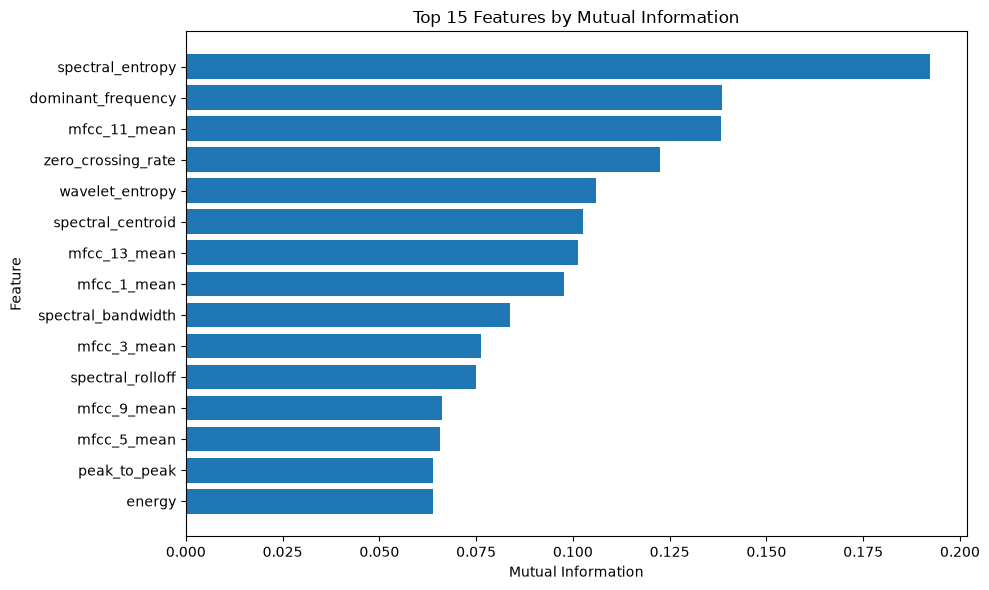

In [18]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_mi["feature"][::-1],
    top_mi["mutual_information"][::-1]
)

plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.title(
    "Top 15 Features by Mutual Information"
)

plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# Random Forest Feature Importance
# ============================================================

rf_selector = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_selector.fit(
    X_train,
    y_train
)

rf_importance_df = pd.DataFrame({
    "feature": feature_columns,
    "rf_importance": rf_selector.feature_importances_
})

rf_importance_df = rf_importance_df.sort_values(
    "rf_importance",
    ascending=False
).reset_index(drop=True)

display(rf_importance_df)

,feature,rf_importance
0,spectral_entropy,0.091141
1,dominant_frequency,0.056178
2,mfcc_11_mean,0.052972
3,zero_crossing_rate,0.041214
4,mfcc_12_mean,0.041164
5,spectral_rolloff,0.039569
6,mfcc_2_mean,0.036796
7,mfcc_13_mean,0.036560
8,wavelet_entropy,0.035129
9,mfcc_4_mean,0.034203


In [20]:
top_rf = rf_importance_df.head(15)

display(top_rf)

,feature,rf_importance
0,spectral_entropy,0.091141
1,dominant_frequency,0.056178
2,mfcc_11_mean,0.052972
3,zero_crossing_rate,0.041214
4,mfcc_12_mean,0.041164
5,spectral_rolloff,0.039569
6,mfcc_2_mean,0.036796
7,mfcc_13_mean,0.036560
8,wavelet_entropy,0.035129
9,mfcc_4_mean,0.034203


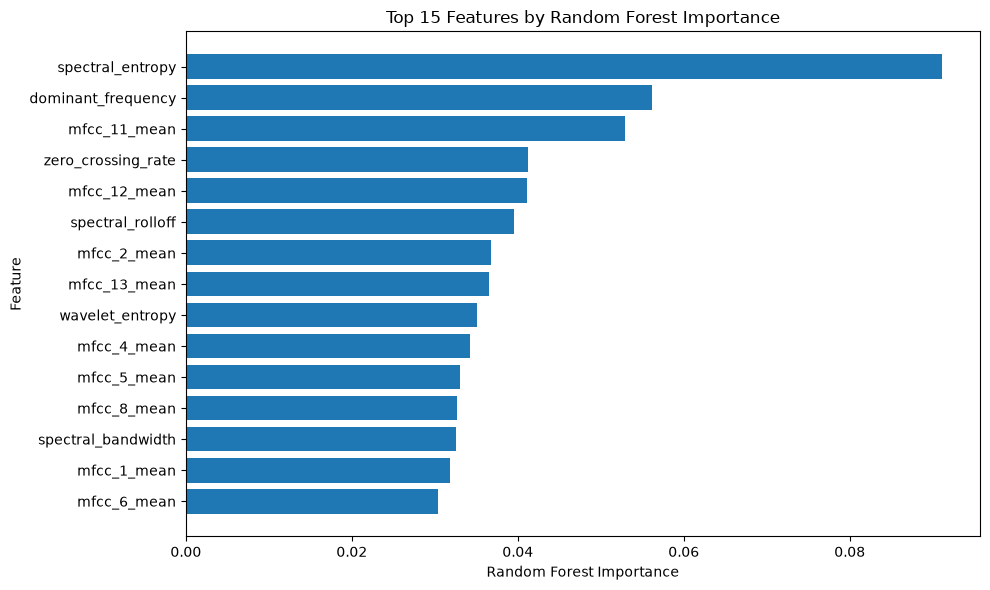

In [21]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_rf["feature"][::-1],
    top_rf["rf_importance"][::-1]
)

plt.xlabel("Random Forest Importance")
plt.ylabel("Feature")
plt.title(
    "Top 15 Features by Random Forest Importance"
)

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# Combined Feature Importance Table
# ============================================================

feature_ranking_df = (
    anova_df
    .merge(
        mi_df,
        on="feature",
        how="inner"
    )
    .merge(
        rf_importance_df,
        on="feature",
        how="inner"
    )
)

print(
    "Combined ranking shape:",
    feature_ranking_df.shape
)

display(feature_ranking_df)

Combined ranking shape: (39, 5)


,feature,anova_f_score,anova_p_value,mutual_information,rf_importance
0,mfcc_11_mean,117.690044,4.915906e-158,0.138341,0.052972
1,spectral_entropy,104.427954,3.556886e-141,0.192166,0.091141
2,mfcc_13_mean,97.980855,7.217214e-133,0.101344,0.036560
3,mfcc_1_mean,71.301847,1.074909e-97,0.097629,0.031877
4,zero_crossing_rate,59.102356,3.540494e-81,0.122478,0.041214
5,peak_to_peak,50.371915,3.437150e-69,0.063932,0.012680
6,spectral_centroid,49.493648,5.618463e-68,0.102544,0.027200
7,spectral_bandwidth,46.761371,3.413310e-64,0.083823,0.032562
8,wavelet_entropy,44.760995,2.048272e-61,0.105945,0.035129
9,mfcc_8_mean,44.312715,8.608218e-61,0.056841,0.032659


In [23]:
feature_ranking_df["anova_rank"] = (
    feature_ranking_df[
        "anova_f_score"
    ]
    .rank(
        ascending=False,
        method="min"
    )
)

feature_ranking_df["mi_rank"] = (
    feature_ranking_df[
        "mutual_information"
    ]
    .rank(
        ascending=False,
        method="min"
    )
)

feature_ranking_df["rf_rank"] = (
    feature_ranking_df[
        "rf_importance"
    ]
    .rank(
        ascending=False,
        method="min"
    )
)

In [25]:
feature_ranking_df["average_rank"] = (
    feature_ranking_df[
        [
            "anova_rank",
            "mi_rank",
            "rf_rank"
        ]
    ]
    .mean(axis=1)
)

In [26]:
feature_ranking_df = (
    feature_ranking_df
    .sort_values(
        "average_rank"
    )
    .reset_index(drop=True)
)

feature_ranking_df[
    [
        "feature",
        "anova_rank",
        "mi_rank",
        "rf_rank",
        "average_rank"
    ]
]

,feature,anova_rank,mi_rank,rf_rank,average_rank
0,spectral_entropy,2.0,1.0,1.0,1.333333
1,mfcc_11_mean,1.0,3.0,3.0,2.333333
2,zero_crossing_rate,5.0,4.0,4.0,4.333333
3,dominant_frequency,13.0,2.0,2.0,5.666667
4,mfcc_13_mean,3.0,7.0,8.0,6.000000
5,wavelet_entropy,9.0,5.0,9.0,7.666667
6,mfcc_1_mean,4.0,8.0,14.0,8.666667
7,spectral_centroid,7.0,6.0,16.0,9.666667
8,spectral_bandwidth,8.0,9.0,13.0,10.000000
9,spectral_rolloff,15.0,11.0,6.0,10.666667


In [27]:
# ============================================================
# Normalized Consensus Score
# ============================================================

feature_ranking_df["anova_score_norm"] = (
    feature_ranking_df["anova_rank"].max()
    - feature_ranking_df["anova_rank"]
    + 1
) / feature_ranking_df["anova_rank"].max()

feature_ranking_df["mi_score_norm"] = (
    feature_ranking_df["mi_rank"].max()
    - feature_ranking_df["mi_rank"]
    + 1
) / feature_ranking_df["mi_rank"].max()

feature_ranking_df["rf_score_norm"] = (
    feature_ranking_df["rf_rank"].max()
    - feature_ranking_df["rf_rank"]
    + 1
) / feature_ranking_df["rf_rank"].max()

feature_ranking_df["consensus_score"] = (
    feature_ranking_df[
        [
            "anova_score_norm",
            "mi_score_norm",
            "rf_score_norm"
        ]
    ]
    .mean(axis=1)
)

feature_ranking_df = (
    feature_ranking_df
    .sort_values(
        "consensus_score",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    feature_ranking_df[
        [
            "feature",
            "anova_f_score",
            "mutual_information",
            "rf_importance",
            "anova_rank",
            "mi_rank",
            "rf_rank",
            "average_rank",
            "consensus_score"
        ]
    ]
)

,feature,anova_f_score,mutual_information,rf_importance,anova_rank,mi_rank,rf_rank,average_rank,consensus_score
0,spectral_entropy,104.427954,0.192166,0.091141,2.0,1.0,1.0,1.333333,0.991453
1,mfcc_11_mean,117.690044,0.138341,0.052972,1.0,3.0,3.0,2.333333,0.965812
2,zero_crossing_rate,59.102356,0.122478,0.041214,5.0,4.0,4.0,4.333333,0.914530
3,dominant_frequency,39.200448,0.138637,0.056178,13.0,2.0,2.0,5.666667,0.880342
4,mfcc_13_mean,97.980855,0.101344,0.036560,3.0,7.0,8.0,6.000000,0.871795
5,wavelet_entropy,44.760995,0.105945,0.035129,9.0,5.0,9.0,7.666667,0.829060
6,mfcc_1_mean,71.301847,0.097629,0.031877,4.0,8.0,14.0,8.666667,0.803419
7,spectral_centroid,49.493648,0.102544,0.027200,7.0,6.0,16.0,9.666667,0.777778
8,spectral_bandwidth,46.761371,0.083823,0.032562,8.0,9.0,13.0,10.000000,0.769231
9,spectral_rolloff,34.028055,0.074976,0.039569,15.0,11.0,6.0,10.666667,0.752137


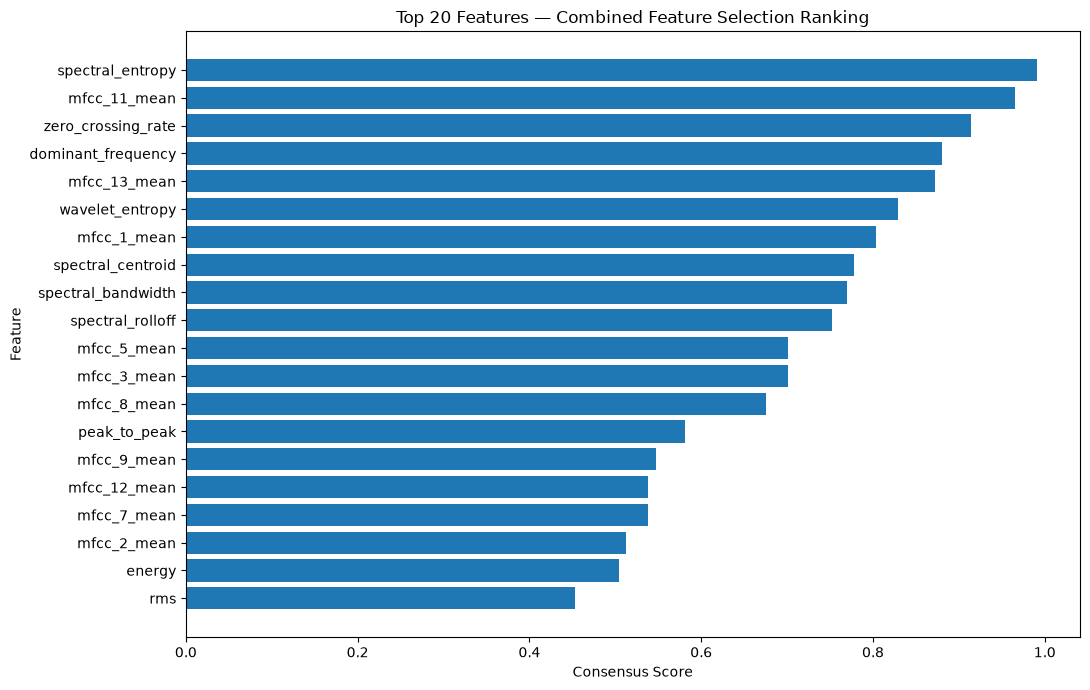

In [28]:
top_consensus = feature_ranking_df.head(20)

plt.figure(figsize=(11, 7))

plt.barh(
    top_consensus["feature"][::-1],
    top_consensus["consensus_score"][::-1]
)

plt.xlabel("Consensus Score")
plt.ylabel("Feature")
plt.title(
    "Top 20 Features — Combined Feature Selection Ranking"
)

plt.tight_layout()
plt.show()

In [32]:
# ============================================================
# Recreate Training Correlation Matrix
# ============================================================

train_correlation_matrix = X_train.corr()

print(
    "Training correlation matrix shape:",
    train_correlation_matrix.shape
)

Training correlation matrix shape: (39, 39)


In [33]:
# ============================================================
# Redundancy-Aware Feature Selection
# ============================================================

ranked_features = feature_ranking_df[
    "feature"
].tolist()

selection_corr_threshold = 0.90

selected_features = []

for feature in ranked_features:

    if len(selected_features) == 0:
        selected_features.append(feature)
        continue

    correlations = (
        train_correlation_matrix.loc[
            feature,
            selected_features
        ].abs()
    )

    if correlations.max() < selection_corr_threshold:
        selected_features.append(feature)


print("Original number of features:", len(feature_columns))
print("Selected number of features:", len(selected_features))

print("\nSelected features:")

for i, feature in enumerate(selected_features, start=1):
    print(f"{i:02d}. {feature}")

Original number of features: 39
Selected number of features: 33

Selected features:
01. spectral_entropy
02. mfcc_11_mean
03. zero_crossing_rate
04. dominant_frequency
05. mfcc_13_mean
06. wavelet_entropy
07. mfcc_1_mean
08. spectral_bandwidth
09. spectral_rolloff
10. mfcc_5_mean
11. mfcc_3_mean
12. mfcc_8_mean
13. peak_to_peak
14. mfcc_9_mean
15. mfcc_12_mean
16. mfcc_7_mean
17. mfcc_2_mean
18. energy
19. rms
20. mfcc_6_mean
21. band_energy_500_1000
22. spectral_flatness
23. band_energy_0_500
24. mfcc_4_mean
25. band_energy_1000_1500
26. min
27. mfcc_10_mean
28. skewness
29. mean
30. kurtosis
31. median
32. band_energy_1500_2000
33. max


In [34]:
# ============================================================
# Final Feature Selection Table
# ============================================================

final_feature_selection_df = (
    feature_ranking_df[
        feature_ranking_df["feature"].isin(
            selected_features
        )
    ]
    .copy()
)

final_feature_selection_df = (
    final_feature_selection_df
    .sort_values(
        "consensus_score",
        ascending=False
    )
    .reset_index(drop=True)
)

display(final_feature_selection_df)

,feature,anova_f_score,anova_p_value,mutual_information,rf_importance,anova_rank,mi_rank,rf_rank,average_rank,anova_score_norm,mi_score_norm,rf_score_norm,consensus_score
0,spectral_entropy,104.427954,3.556886e-141,0.192166,0.091141,2.0,1.0,1.0,1.333333,0.974359,1.000000,1.000000,0.991453
1,mfcc_11_mean,117.690044,4.915906e-158,0.138341,0.052972,1.0,3.0,3.0,2.333333,1.000000,0.948718,0.948718,0.965812
2,zero_crossing_rate,59.102356,3.540494e-81,0.122478,0.041214,5.0,4.0,4.0,4.333333,0.897436,0.923077,0.923077,0.914530
3,dominant_frequency,39.200448,1.172736e-53,0.138637,0.056178,13.0,2.0,2.0,5.666667,0.692308,0.974359,0.974359,0.880342
4,mfcc_13_mean,97.980855,7.217214e-133,0.101344,0.036560,3.0,7.0,8.0,6.000000,0.948718,0.846154,0.820513,0.871795
5,wavelet_entropy,44.760995,2.048272e-61,0.105945,0.035129,9.0,5.0,9.0,7.666667,0.794872,0.897436,0.794872,0.829060
6,mfcc_1_mean,71.301847,1.074909e-97,0.097629,0.031877,4.0,8.0,14.0,8.666667,0.923077,0.820513,0.666667,0.803419
7,spectral_bandwidth,46.761371,3.413310e-64,0.083823,0.032562,8.0,9.0,13.0,10.000000,0.820513,0.794872,0.692308,0.769231
8,spectral_rolloff,34.028055,2.132946e-46,0.074976,0.039569,15.0,11.0,6.0,10.666667,0.641026,0.743590,0.871795,0.752137
9,mfcc_5_mean,37.183668,7.854703e-51,0.065770,0.032991,14.0,13.0,11.0,12.666667,0.666667,0.692308,0.743590,0.700855


In [35]:
selected_features_df = pd.DataFrame({
    "feature": selected_features
})

selected_features_df.to_csv(
    feature_selection_dir / "selected_features.csv",
    index=False
)

final_feature_selection_df.to_csv(
    feature_selection_dir /
    "final_feature_selection_ranking.csv",
    index=False
)

print("Selected feature list saved successfully.")

Selected feature list saved successfully.


In [38]:
# ============================================================
# Recreate Reduced Training/Test Feature Matrices
# ============================================================

X_train_selected = train_df[
    selected_features
].copy()

X_test_selected = test_df[
    selected_features
].copy()

print("Original training feature shape:", X_train.shape)
print("Selected training feature shape:", X_train_selected.shape)

print("\nSelected testing feature shape:", X_test_selected.shape)

Original training feature shape: (4142, 39)
Selected training feature shape: (4142, 33)

Selected testing feature shape: (2756, 33)


In [39]:
# ============================================================
# Final Feature Selection Validation
# ============================================================

print("========== NOTEBOOK 07 VALIDATION ==========")

print("Original feature count:", len(feature_columns))
print("Selected feature count:", len(selected_features))

print("\nSelected features:")
for i, feature in enumerate(selected_features, start=1):
    print(f"{i:02d}. {feature}")

print("\nTraining matrix shape:", X_train_selected.shape)
print("Testing matrix shape:", X_test_selected.shape)

print(
    "\nMissing values - train:",
    X_train_selected.isna().sum().sum()
)

print(
    "Missing values - test:",
    X_test_selected.isna().sum().sum()
)

print(
    "Infinite values - train:",
    np.isinf(X_train_selected.to_numpy()).sum()
)

print(
    "Infinite values - test:",
    np.isinf(X_test_selected.to_numpy()).sum()
)

print("\nNotebook 07 feature selection complete.")

========== NOTEBOOK 07 VALIDATION ==========
Original feature count: 39
Selected feature count: 33

Selected features:
01. spectral_entropy
02. mfcc_11_mean
03. zero_crossing_rate
04. dominant_frequency
05. mfcc_13_mean
06. wavelet_entropy
07. mfcc_1_mean
08. spectral_bandwidth
09. spectral_rolloff
10. mfcc_5_mean
11. mfcc_3_mean
12. mfcc_8_mean
13. peak_to_peak
14. mfcc_9_mean
15. mfcc_12_mean
16. mfcc_7_mean
17. mfcc_2_mean
18. energy
19. rms
20. mfcc_6_mean
21. band_energy_500_1000
22. spectral_flatness
23. band_energy_0_500
24. mfcc_4_mean
25. band_energy_1000_1500
26. min
27. mfcc_10_mean
28. skewness
29. mean
30. kurtosis
31. median
32. band_energy_1500_2000
33. max

Training matrix shape: (4142, 33)
Testing matrix shape: (2756, 33)

Missing values - train: 0
Missing values - test: 0
Infinite values - train: 0
Infinite values - test: 0

Notebook 07 feature selection complete.


In [40]:
selected_features_df = pd.DataFrame({
    "feature": selected_features
})

selected_features_df.to_csv(
    feature_selection_dir / "selected_features.csv",
    index=False
)

print("Selected feature list saved successfully.")

Selected feature list saved successfully.


In [41]:
# ============================================================
# Final Feature Selection Validation
# ============================================================

print("========== NOTEBOOK 07 VALIDATION ==========")

print("Original feature count:", len(feature_columns))
print("Selected feature count:", len(selected_features))

print("\nSelected features:")
for i, feature in enumerate(selected_features, start=1):
    print(f"{i:02d}. {feature}")

print("\nTraining matrix shape:", X_train_selected.shape)
print("Testing matrix shape:", X_test_selected.shape)

print(
    "\nMissing values - train:",
    X_train_selected.isna().sum().sum()
)

print(
    "Missing values - test:",
    X_test_selected.isna().sum().sum()
)

print(
    "Infinite values - train:",
    np.isinf(X_train_selected.to_numpy()).sum()
)

print(
    "Infinite values - test:",
    np.isinf(X_test_selected.to_numpy()).sum()
)

print("\nNotebook 07 feature selection complete.")

========== NOTEBOOK 07 VALIDATION ==========
Original feature count: 39
Selected feature count: 33

Selected features:
01. spectral_entropy
02. mfcc_11_mean
03. zero_crossing_rate
04. dominant_frequency
05. mfcc_13_mean
06. wavelet_entropy
07. mfcc_1_mean
08. spectral_bandwidth
09. spectral_rolloff
10. mfcc_5_mean
11. mfcc_3_mean
12. mfcc_8_mean
13. peak_to_peak
14. mfcc_9_mean
15. mfcc_12_mean
16. mfcc_7_mean
17. mfcc_2_mean
18. energy
19. rms
20. mfcc_6_mean
21. band_energy_500_1000
22. spectral_flatness
23. band_energy_0_500
24. mfcc_4_mean
25. band_energy_1000_1500
26. min
27. mfcc_10_mean
28. skewness
29. mean
30. kurtosis
31. median
32. band_energy_1500_2000
33. max

Training matrix shape: (4142, 33)
Testing matrix shape: (2756, 33)

Missing values - train: 0
Missing values - test: 0
Infinite values - train: 0
Infinite values - test: 0

Notebook 07 feature selection complete.


# Notebook 07 — Feature Selection: Final Summary

## Objective

This notebook performed systematic feature selection on the 39 handcrafted
respiratory-sound features generated in Notebook 05.

The selection process used multiple complementary Data Mining approaches:

1. Correlation-based redundancy analysis
2. ANOVA F-score
3. Mutual Information
4. Random Forest feature importance
5. Consensus feature ranking
6. Redundancy-aware feature selection

## Leakage Prevention

The official recording-level training split was used for feature-selection
analysis.

The official test recordings were not used to calculate ANOVA scores,
Mutual Information scores, Random Forest feature importance, or the
consensus feature ranking.

This prevents test-set information from influencing feature selection.

## Feature Selection Strategy

Features were first ranked using ANOVA, Mutual Information, and Random
Forest importance.

The rankings were combined into a consensus ranking.

Highly redundant features were then filtered using a correlation threshold
of |r| >= 0.90. A feature was retained when it provided a strong consensus
ranking while avoiding excessive correlation with already-selected
features.

## Results

Original handcrafted features: **39**

Selected features: **[INSERT SELECTED FEATURE COUNT]**

The final selected feature list was saved to:

`data/processed/feature_selection/selected_features.csv`

The complete feature-selection ranking was saved to:

`data/processed/feature_selection/feature_selection_ranking.csv`

Additional ANOVA, Mutual Information, Random Forest, and correlation
analysis results were also saved in the feature-selection output directory.

## Important Methodological Note

The original 39-feature dataset has not been modified or overwritten.

The selected features represent a reduced feature set for subsequent
classical machine-learning experiments.

Feature scaling, PCA, clustering, model training, and final evaluation
will be performed in later notebooks.

## Conclusion

Notebook 07 established a systematic and reproducible feature-selection
pipeline rather than selecting features manually.

The resulting feature set balances:

- discriminative ability,
- nonlinear information,
- model-based importance,
- and feature redundancy.

**Notebook 07 feature selection complete.**